In [ ]:
import pandas as pd
df = pd.read_csv("wandbs_logs/ast_trials.csv")
df = df.replace({"none": "None", "gelu": "GELU", "relu": "ReLU", "layer": "Layer"})
columns = ["Name", "State", "freeze_layers", "eval/accuracy", "batch_size", "normalisation", "activation_fn", "learning_rate", "seed"]
df = df[columns]
df = df[df["State"] == "finished"]
df.head()

,Name,State,freeze_layers,eval/accuracy,batch_size,normalisation,activation_fn,learning_rate,seed
0,trial_52,finished,5,0.665049,4,None,GELU,0.000177,42
1,trial_51,finished,6,0.614078,4,Layer,ReLU,0.000013,42
2,trial_50,finished,0,0.669903,4,None,None,0.000058,42
3,trial_49,finished,3,0.616505,4,None,ReLU,0.000613,42
4,trial_48,finished,0,0.652913,4,None,None,0.000040,42


In [14]:
len(df)

52

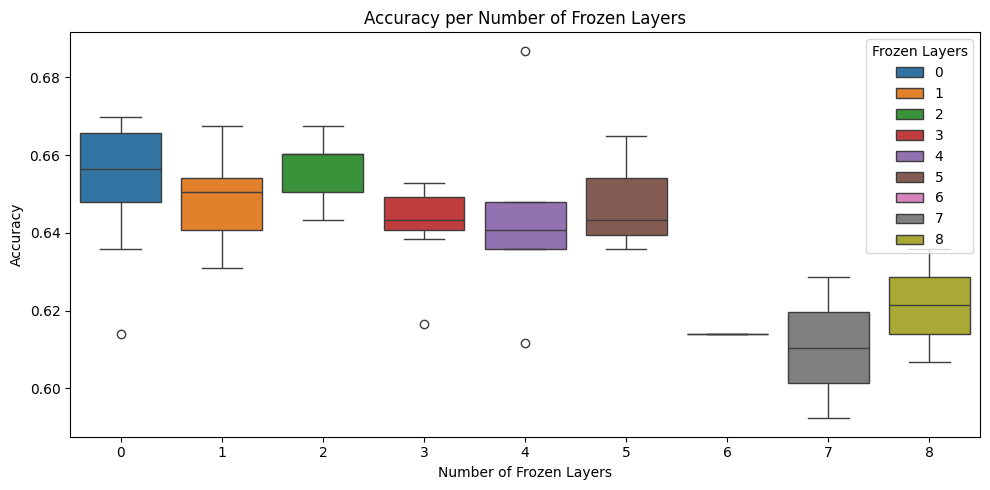

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='freeze_layers', y='eval/accuracy', hue='freeze_layers',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

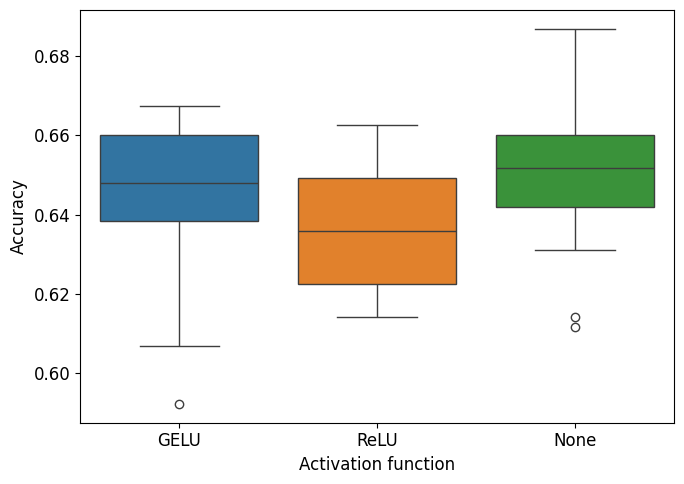

In [ ]:
import seaborn as sns  # with 11
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})
# Create the plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='activation_fn', y='eval/accuracy', hue='activation_fn',  palette='tab10')

# Adjust plot
plt.xlabel("Activation function")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("nas_activation_functions.pdf", format="pdf", bbox_inches="tight")
plt.show()

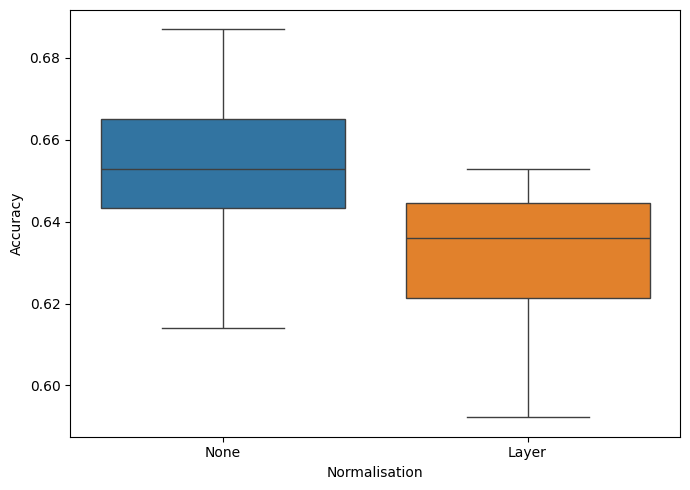

In [ ]:
import seaborn as sns  # with 11
import matplotlib.pyplot as plt
# Create the plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='normalisation', y='eval/accuracy', hue='normalisation',  palette='tab10')

# Adjust plot
plt.xlabel("Normalisation")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

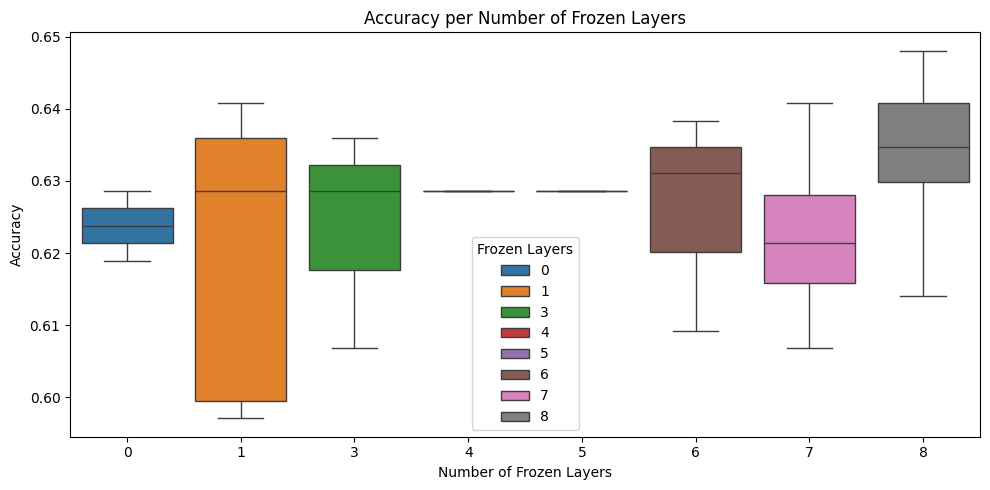

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Create the plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='freeze_layers', y='eval/accuracy', hue='freeze_layers',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

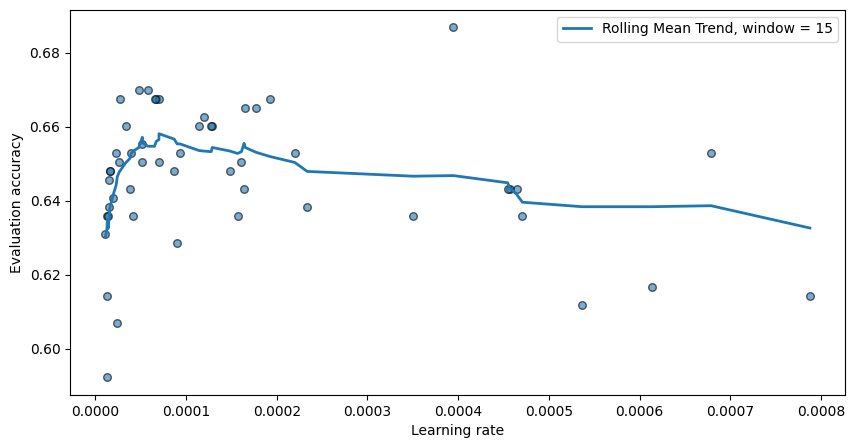

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Assume df is already loaded with columns "dropout_top" and "eval/accuracy"
x = df["learning_rate"].values
y = df["eval/accuracy"].values

# Fit linear regression
X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)
coef = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

# Prepare data for plotting
order = np.argsort(x)
x_sorted = x[order]
y_pred_sorted = model.predict(x_sorted.reshape(-1, 1))

# Compute rolling mean for trend line
window = max(15, len(x) // 20)
y_smooth = pd.Series(y[order]).rolling(window= window, min_periods=3, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, alpha=0.6, edgecolors='k', s=30)
ax.plot(x_sorted, y_smooth, lw=2, label=f'Rolling Mean Trend, window = {window}')

ax.set_xlabel("Learning rate")
ax.set_ylabel("Evaluation accuracy")
ax.legend()
plt.savefig("learning_rate_vs_eval_acc.pdf", format="pdf", bbox_inches="tight")
plt.show()

C:\Users\Marina\AppData\Local\Temp\ipykernel_10232\744773637.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Frozen Layers")


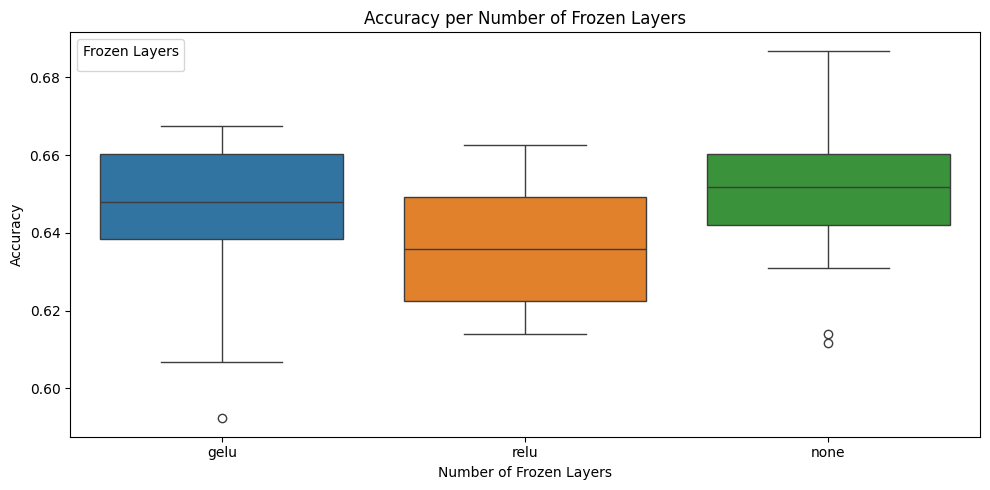

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='activation_fn', y='eval/accuracy', hue='activation_fn',  palette='tab10')

# Adjust plot
plt.xlabel("Number of Frozen Layers")
plt.ylabel("Accuracy")
plt.title("Accuracy per Number of Frozen Layers")
plt.legend(title="Frozen Layers")
plt.tight_layout()
plt.show()

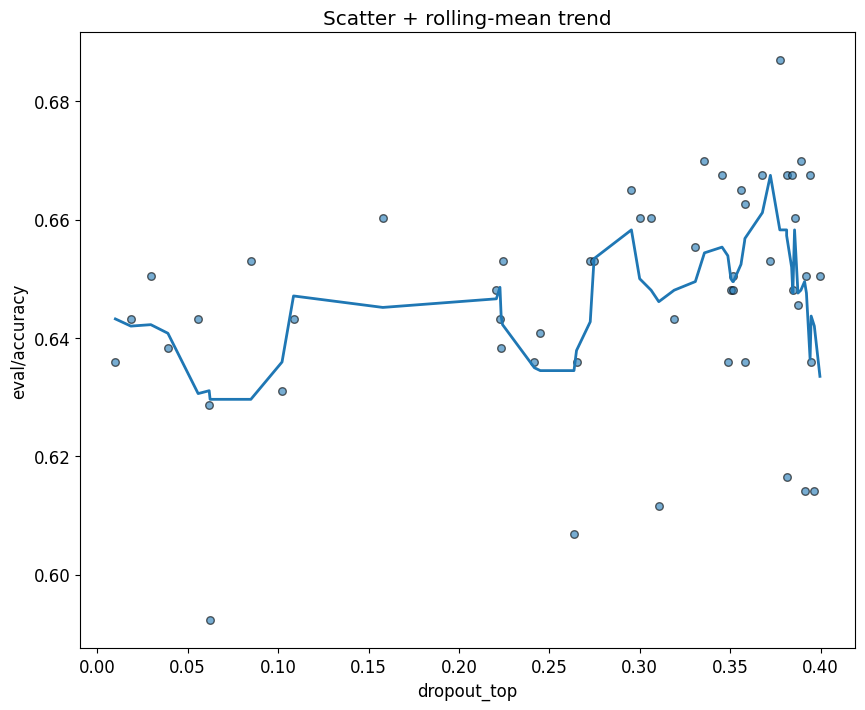

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume df has columns "dropout_top" and "eval/accuracy"
x = df["dropout_top"].values
y = df["eval/accuracy"].values

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(x, y, alpha=0.6, edgecolors="k", s=30)

order = np.argsort(x)
x_sorted = x[order]
y_sorted = y[order]
window = max(5, len(x)//20) 
y_smooth = pd.Series(y_sorted).rolling(window, min_periods=1, center=True).mean()

ax.plot(x_sorted, y_smooth, lw=2)

ax.set_xlabel("dropout_top")
ax.set_ylabel("eval/accuracy")
ax.set_title("Scatter + rolling‑mean trend")
plt.show()


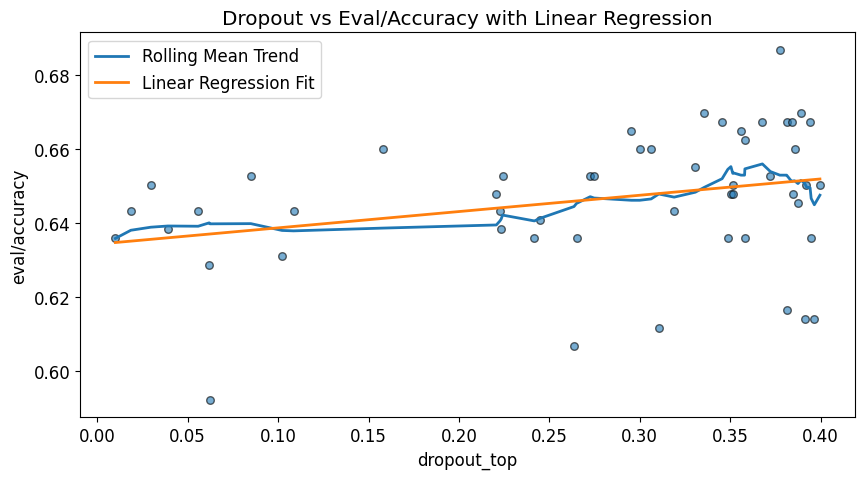

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x = df["dropout_top"].values
y = df["eval/accuracy"].values

# Fit linear regression
X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)
coef = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

# Prepare data for plotting
order = np.argsort(x)
x_sorted = x[order]
y_pred_sorted = model.predict(x_sorted.reshape(-1, 1))

# Compute rolling mean for trend line
window = max(8, len(x) // 20)
y_smooth = pd.Series(y[order]).rolling(window= 20, min_periods=4, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, alpha=0.6, edgecolors='k', s=30)
ax.plot(x_sorted, y_smooth, lw=2, label='Rolling Mean Trend')
ax.plot(x_sorted, y_pred_sorted, lw=2, label='Linear Regression Fit')

ax.set_xlabel("dropout_top")
ax.set_ylabel("eval/accuracy")
ax.set_title("Dropout vs Eval/Accuracy with Linear Regression")
ax.legend()

plt.show()


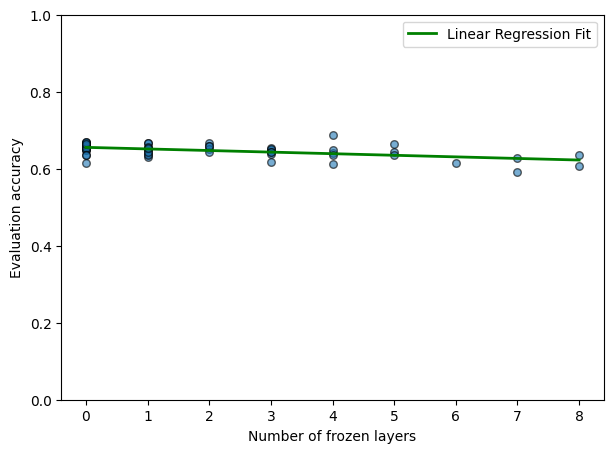

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Assume df is already loaded with columns "dropout_top" and "eval/accuracy"
x = df["freeze_layers"].values
y = df["eval/accuracy"].values

# Fit linear regression
X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)
coef = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

# Prepare data for plotting
order = np.argsort(x)
x_sorted = x[order]
y_pred_sorted = model.predict(x_sorted.reshape(-1, 1))

# Compute rolling mean for trend line
window = max(8, len(x) // 20)
y_smooth = pd.Series(y[order]).rolling(window= 20, min_periods=4, center=True).mean()

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.6, edgecolors='k', s=30)
#ax.plot(x_sorted, y_smooth, lw=2, label='Rolling Mean Trend')
ax.plot(x_sorted, y_pred_sorted, lw=2, label='Linear Regression Fit', color = "g")

ax.set_xlabel("Number of frozen layers")
ax.set_ylabel("Evaluation accuracy")
ax.set_ylim(0,1)
#ax.set_title("Dropout vs Eval/Accuracy with Linear Regression")
ax.legend()
#plt.savefig("figures/nas_frozen_layesrs.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [6]:
df[["eval/accuracy"]] = df[["eval/accuracy"]] *100
df[["eval/accuracy"]].std()

eval/accuracy    1.834786
dtype: float64

In [7]:
df[["eval/accuracy"]].mean()

eval/accuracy    64.65646
dtype: float64

# Three best models runs 

In [11]:
import pandas as pd
df = pd.read_csv("wandbs_logs/5_seeds.csv")
df.tail(10)

,train/epoch,best_lin_fake_1e-7_5 - eval/accuracy,best_lin_fake_1e-7_5 - eval/accuracy__MIN,best_lin_fake_1e-7_5 - eval/accuracy__MAX,best_lin_fake_1e-7_5 - _step,best_lin_fake_1e-7_5 - _step__MIN,best_lin_fake_1e-7_5 - _step__MAX,best_lin_fake_1e-7_4 - eval/accuracy,best_lin_fake_1e-7_4 - eval/accuracy__MIN,best_lin_fake_1e-7_4 - eval/accuracy__MAX,...,best_lin_fake_1e-7_2 - eval/accuracy__MAX,best_lin_fake_1e-7_2 - _step,best_lin_fake_1e-7_2 - _step__MIN,best_lin_fake_1e-7_2 - _step__MAX,best_lin_fake_1e-7 - eval/accuracy,best_lin_fake_1e-7 - eval/accuracy__MIN,best_lin_fake_1e-7 - eval/accuracy__MAX,best_lin_fake_1e-7 - _step,best_lin_fake_1e-7 - _step__MIN,best_lin_fake_1e-7 - _step__MAX
39,21.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.657767,0.657767,0.657767,41.0,41.0,41.0
40,21.99,0.622353,0.618824,0.625882,44.0,43.0,45.0,0.612385,0.612385,0.612385,...,NaN,NaN,NaN,NaN,0.674757,0.674757,0.674757,43.0,43.0,43.0
41,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.584541,43.0,43.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN
42,22.99,NaN,NaN,NaN,NaN,NaN,NaN,0.614679,0.614679,0.614679,...,0.586957,45.0,45.0,45.0,NaN,NaN,NaN,NaN,NaN,NaN
43,23.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.657767,0.657767,0.657767,45.0,45.0,45.0
44,24.00,NaN,NaN,NaN,NaN,NaN,NaN,0.619266,0.619266,0.619266,...,0.579710,47.0,47.0,47.0,0.667476,0.660194,0.674757,48.0,47.0,49.0
45,24.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.599034,50.0,49.0,51.0,NaN,NaN,NaN,NaN,NaN,NaN
46,25.00,NaN,NaN,NaN,NaN,NaN,NaN,0.633028,0.633028,0.633028,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,26.00,NaN,NaN,NaN,NaN,NaN,NaN,0.621560,0.621560,0.621560,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,27.00,NaN,NaN,NaN,NaN,NaN,NaN,0.622706,0.612385,0.633028,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
columns = df.columns
columns_to_drop = [column for column in columns if (column.endswith("MAX") or column.endswith("MIN") or column.endswith("step"))]
df = df.drop(columns=columns_to_drop)
df.head(20)

,train/epoch,best_lin_fake_1e-7_5 - eval/accuracy,best_lin_fake_1e-7_4 - eval/accuracy,best_lin_fake_1e-7_3 - eval/accuracy,best_lin_fake_1e-7_2 - eval/accuracy,best_lin_fake_1e-7 - eval/accuracy
0,0.99,0.400000,NaN,0.425234,0.345411,0.339806
1,1.00,NaN,0.321101,NaN,NaN,NaN
2,1.99,0.456471,NaN,NaN,NaN,NaN
3,2.00,NaN,0.479358,0.471963,0.388889,0.422330
4,2.99,NaN,NaN,0.521028,0.442029,0.504854
5,3.00,0.555294,0.511468,NaN,NaN,NaN
6,3.99,NaN,0.545872,0.532710,NaN,0.516990
7,4.00,0.571765,NaN,NaN,0.500000,NaN
8,4.99,0.562353,0.573394,NaN,0.541063,NaN
9,5.00,NaN,NaN,0.532710,NaN,0.502427


In [ ]:
import numpy as np
def fill_with_nearest_epoch(df, epoch_col="train/epoch", acc_cols=None):
    df = df.copy().reset_index(drop=True)
    if acc_cols is None:
        acc_cols = [c for c in df.columns if "accuracy" in c]
    # Precompute epochs as numpy array for distance calculations
    epochs = df[epoch_col].to_numpy(dtype=float)
    for col in acc_cols:
        values = df[col].to_numpy(dtype=float)
        nan_mask = np.isnan(values)
        for i in np.where(nan_mask)[0]:
            # Compute distances to rows where value is not NaN
            epoch_train = epochs[i]
            if float(epoch_train).is_integer:
                filling = values[i-1]
            else:
                filling = values[i+1]
            df.loc[i, col] = filling
    return df

filled_df = fill_with_nearest_epoch(df)



In [ ]:
filled_df["train/epoch"] =pd.to_numeric(filled_df["train/epoch"], downcast='integer')
filled_df

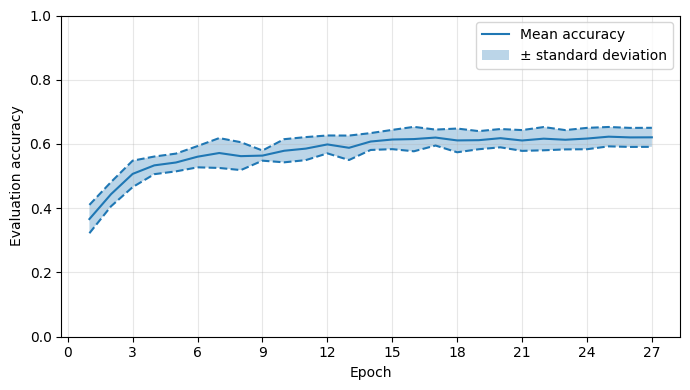

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
df = filled_df.copy()
import matplotlib.ticker as ticker
acc_cols = [col for col in list(filled_df.columns.values) if col.endswith("accuracy")]
matplotlib.rcParams.update({'font.size': 10})
# compute mean and std across the runs
df["mean_acc"] = df[acc_cols].mean(axis=1)
df["std_acc"] = df[acc_cols].std(axis=1)

# plot
plt.figure(figsize=(7, 4))
plt.plot(df["train/epoch"], df["mean_acc"],color='C0', label="Mean accuracy")
plt.plot(df["train/epoch"], df["mean_acc"] + df["std_acc"],'--', color='C0')
plt.plot(df["train/epoch"], df["mean_acc"] - df["std_acc"],'--', color='C0')
plt.fill_between(
    df["train/epoch"],
    df["mean_acc"] - df["std_acc"],
    df["mean_acc"] + df["std_acc"],
    alpha=0.3,
    label="± standard deviation"
)
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylim(0,1)
plt.xlabel("Epoch")
plt.ylabel("Evaluation accuracy")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.savefig("figures\5_runs_average_ranges_grid.pdf", format="pdf", bbox_inches="tight")
plt.show()